<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/Class18_Lab18_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 18: Model Evaluation - Metrics That Matter
## Confusion Matrix, ROC/PR Curves, and Threshold Analysis for Imbalanced Classification

**Data:** Kaggle Credit Card Fraud Detection - 284,807 transactions, 492 fraud (0.172%)  
**Packages:** pandas, numpy, scikit-learn, matplotlib, seaborn

In [1]:
# -----------------------------------------------------------
# SETUP - Run this cell first.
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Setup complete')

Setup complete


## Part 1: The Accuracy Paradox - Guided Walkthrough

In [2]:
# Step 1: Load data
# Option A: Upload directly in Colab
from google.colab import files
uploaded = files.upload()  # select creditcard.csv when prompted
import io
df = pd.read_csv(io.BytesIO(uploaded['creditcard.csv']))

# Option B: Load from Google Drive (uncomment if preferred)
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

print(f'Dataset shape: {df.shape}')
print('\nClass distribution:')
print(df['Class'].value_counts())
print(f'Fraud rate: {df["Class"].mean():.4%}')

Saving creditcard.csv to creditcard.csv
Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%


In [3]:
# Step 2: Inspect the data
print('First 5 rows:')
print(df.head())
print(f'Missing values: {df.isnull().sum().sum()}')
print('\nTransaction amount stats:')
print(df['Amount'].describe())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [4]:
# Step 3: Prepare features and target
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} transactions ({y_train.sum()} frauds)')
print(f'Test set:     {X_test.shape[0]:,} transactions ({y_test.sum()} frauds)')

Training set: 227,845 transactions (394 frauds)
Test set:     56,962 transactions (98 frauds)


In [5]:
# Step 4: Naive baseline - predict not-fraud for everything
naive_predictions = np.zeros(len(y_test))
naive_accuracy = (naive_predictions == y_test).mean()
print(f'Naive baseline accuracy: {naive_accuracy:.4%}')
print(f'Naive baseline recall (fraud): {recall_score(y_test, naive_predictions):.4%}')
print('99.83% accuracy, 0% recall. The accuracy paradox in action.')

Naive baseline accuracy: 99.8280%
Naive baseline recall (fraud): 0.0000%
99.83% accuracy, 0% recall. The accuracy paradox in action.


In [6]:
# Step 5: Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_prob = log_reg.predict_proba(X_test)[:, 1]
y_pred = log_reg.predict(X_test)

print(f'Model accuracy: {(y_pred == y_test).mean():.4%}')
print('But accuracy alone is misleading. See confusion matrix below.')

Model accuracy: 99.9157%
But accuracy alone is misleading. See confusion matrix below.


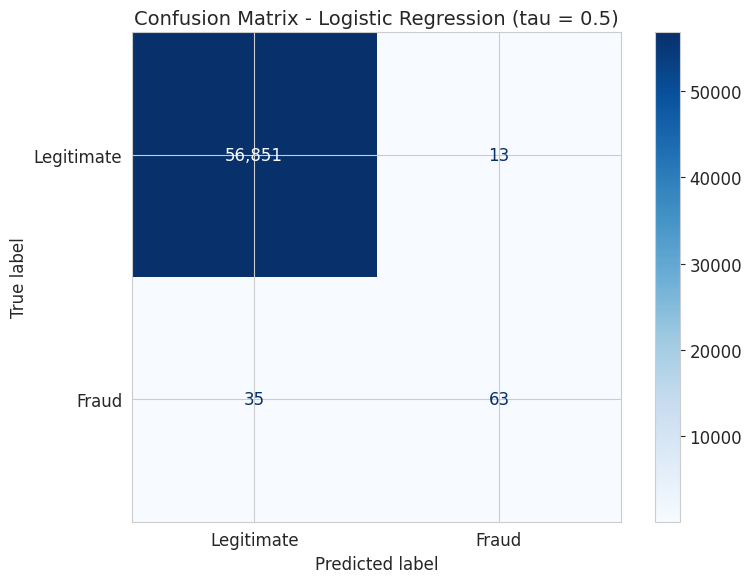

True Positives  (fraud caught):   63
False Negatives (fraud missed):   35
False Positives (legit blocked):  13
True Negatives  (legit approved): 56,851


In [7]:
# Step 6: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix - Logistic Regression (tau = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (fraud caught):   {tp}')
print(f'False Negatives (fraud missed):   {fn}')
print(f'False Positives (legit blocked):  {fp}')
print(f'True Negatives  (legit approved): {tn:,}')

In [8]:
# Step 7: Classification report
print('Classification Report (tau = 0.5):')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print('Focus on the FRAUD row.')
print('macro avg = unweighted mean. weighted avg = dominated by majority class.')

Classification Report (tau = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Focus on the FRAUD row.
macro avg = unweighted mean. weighted avg = dominated by majority class.


## Part 2: ROC Curve, PR Curve, and Threshold Analysis

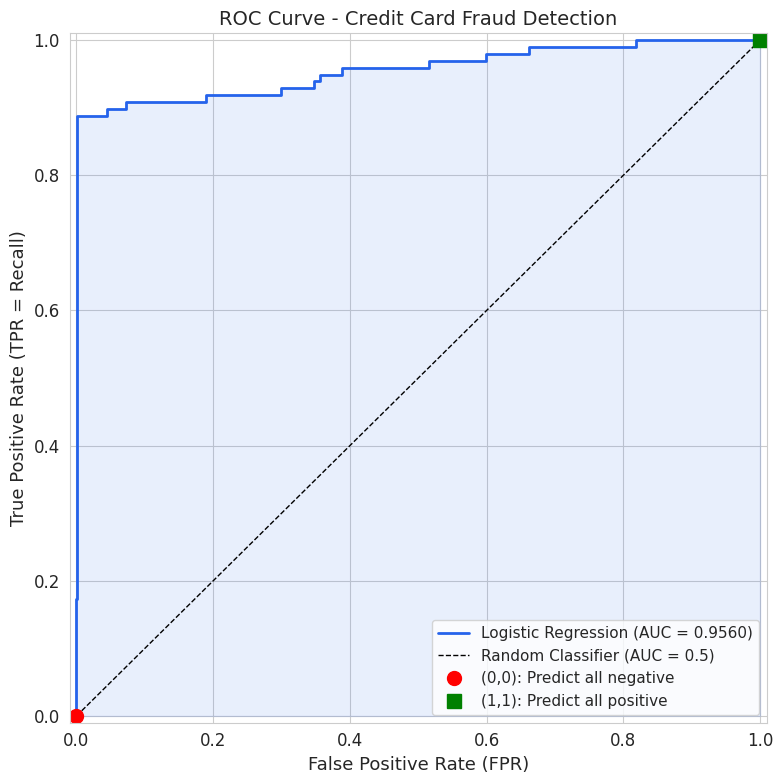

AUC = 0.9560
Interpretation: 95.6% probability the model ranks a random fraud
higher than a random legitimate transaction.


In [9]:
# Step 1: ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2,
        label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
ax.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve - Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f'AUC = {auc_score:.4f}')
print(f'Interpretation: {auc_score:.1%} probability the model ranks a random fraud')
print('higher than a random legitimate transaction.')

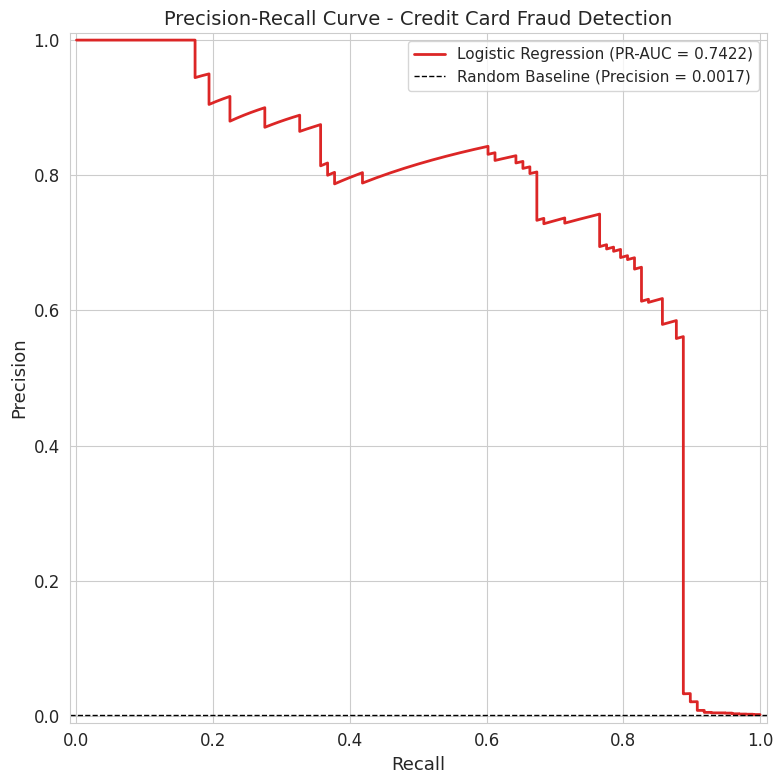

PR-AUC = 0.7422
PR curve is a harder test than ROC: it ignores TN and focuses on fraud-class performance.


In [10]:
# Step 2: Precision-Recall curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve - Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f'PR-AUC = {pr_auc:.4f}')
print('PR curve is a harder test than ROC: it ignores TN and focuses on fraud-class performance.')

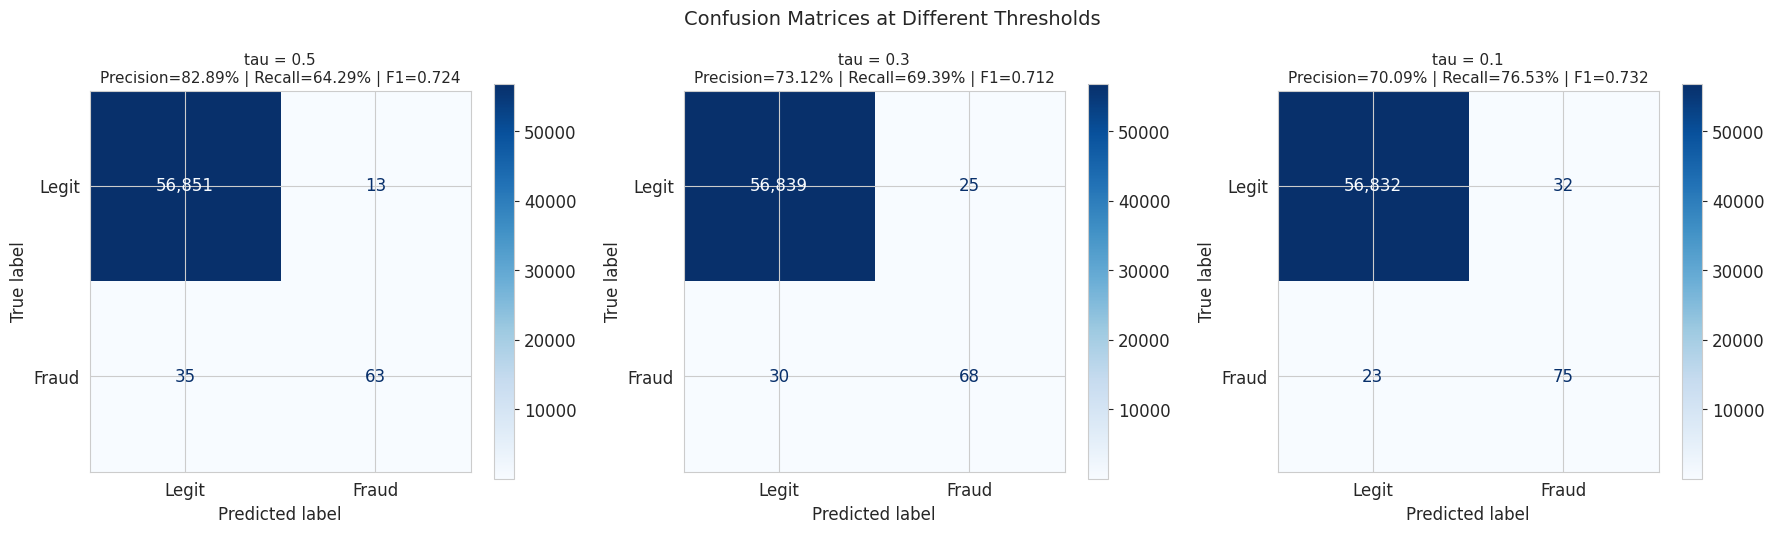

As tau decreases: Recall up (more fraud caught), Precision down (more false alarms).


In [11]:
# Step 3: Confusion matrices at 3 thresholds
thresholds_to_test = [0.5, 0.3, 0.1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, tau in enumerate(thresholds_to_test):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, y_pred_tau)
    prec = precision_score(y_test, y_pred_tau, zero_division=0)
    rec  = recall_score(y_test, y_pred_tau)
    f1   = f1_score(y_test, y_pred_tau)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_tau, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(
        f'tau = {tau}\nPrecision={prec:.2%} | Recall={rec:.2%} | F1={f1:.3f}',
        fontsize=11
    )

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('As tau decreases: Recall up (more fraud caught), Precision down (more false alarms).')

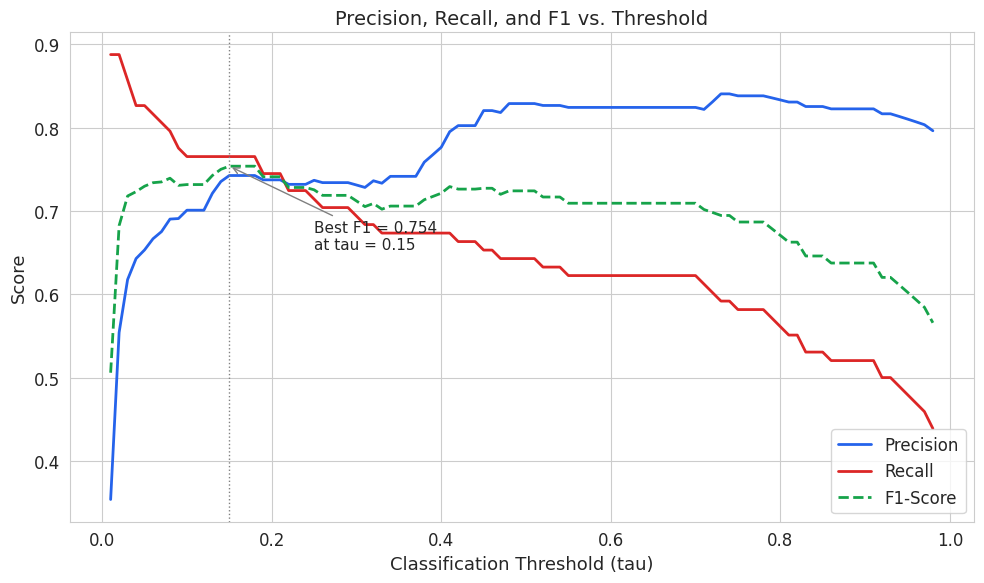

Optimal threshold for F1: tau = 0.15 (F1 = 0.754)
F1 assumes equal cost of FP and FN.
In fraud detection, you may prefer lower tau to maximize Recall.


In [12]:
# Step 4: Find F1-optimal threshold
f1_scores_list   = []
prec_scores_list = []
rec_scores_list  = []
threshold_range  = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores_list.append(f1_score(y_test, y_pred_tau, zero_division=0))
    prec_scores_list.append(precision_score(y_test, y_pred_tau, zero_division=0))
    rec_scores_list.append(recall_score(y_test, y_pred_tau, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, prec_scores_list, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, rec_scores_list,  label='Recall',    color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores_list,   label='F1-Score',  color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores_list)]
best_f1  = max(f1_scores_list)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(
    f'Best F1 = {best_f1:.3f}\nat tau = {best_tau:.2f}',
    xy=(best_tau, best_f1),
    xytext=(best_tau + 0.1, best_f1 - 0.1),
    fontsize=11,
    arrowprops=dict(arrowstyle='->', color='gray')
)
ax.set_xlabel('Classification Threshold (tau)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'Optimal threshold for F1: tau = {best_tau:.2f} (F1 = {best_f1:.3f})')
print('F1 assumes equal cost of FP and FN.')
print('In fraud detection, you may prefer lower tau to maximize Recall.')

## Part 3: Your Turn - Capacity-Constrained Fraud Investigation

**Scenario:** The fraud team can investigate at most **500** flagged transactions per day.  
**Task:** Find the lowest threshold tau that keeps flagged transactions within capacity.

In [13]:
## Exercise: capacity-constrained threshold selection

max_investigations = 500

for tau in np.arange(0.01, 0.99, 0.01):
    # Count how many transactions are flagged at this threshold
    n_flagged = (y_prob >= tau).sum()

    if n_flagged <= max_investigations:
        # Build binary prediction array at this threshold
        y_pred_capacity = (y_prob >= tau).astype(int)

        # Compute Recall and Precision at this operating point
        rec  = recall_score(y_test, y_pred_capacity)
        prec = precision_score(y_test, y_pred_capacity, zero_division=0)

        print(f'tau = {tau:.2f} -> {n_flagged} flagged | Recall = {rec:.2%} | Precision = {prec:.2%}')
        break

# Interpretation
print('\n--- Interpretation ---')
print(f'At tau = {tau:.2f}: {n_flagged} transactions flagged per day (within 500-case cap).')
print(f'Recall = {rec:.2%}: the team surfaces {rec:.2%} of all actual fraud.')
print(f'Precision = {prec:.2%}: {prec:.2%} of flagged cases are true fraud.')
print()
if rec >= 0.80:
    print('Recommendation to VP of Risk:')
    print('  Recall is strong. The 500-case cap is manageable at this threshold.')
    print('  Monitor false-alarm rate to protect customer experience.')
else:
    print('Recommendation to VP of Risk:')
    print('  Recall is below 80%. Many frauds are being missed under this cap.')
    print('  Options: expand team capacity, triage high-value transactions only,')
    print('           or adopt a two-stage model to pre-filter low-risk alerts.')
print()
print('Key insight: the optimal threshold is a business decision, not a statistical one.')

tau = 0.01 -> 246 flagged | Recall = 88.78% | Precision = 35.37%

--- Interpretation ---
At tau = 0.01: 246 transactions flagged per day (within 500-case cap).
Recall = 88.78%: the team surfaces 88.78% of all actual fraud.
Precision = 35.37%: 35.37% of flagged cases are true fraud.

Recommendation to VP of Risk:
  Recall is strong. The 500-case cap is manageable at this threshold.
  Monitor false-alarm rate to protect customer experience.

Key insight: the optimal threshold is a business decision, not a statistical one.
